<a href="https://colab.research.google.com/github/anferivera/Fisica_Computacional_1/blob/main/15_seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p><img alt="numpy logo" height="150px" src="https://seaborn.pydata.org/_images/logo-wide-lightbg.svg" align="left" hspace="10px" vspace="0px"></p>

https://seaborn.pydata.org/

<h1> Física computacional 1</h1>
Prof: Andrés F. Rivera R.

<h1> seaborn: statistical data visualization</h1>

**Michaesl L. Waskom** A paper describing seaborn has been published in the Journal of Open Source Software:
https://joss.theoj.org/papers/10.21105/joss.03021


seaborn is a library for making statistical graphics in Python. It provides a high-level interface
to matplotlib and integrates closely with pandas data structures....

In [48]:
# Import numpy and pandas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In the next part we will explored the example done in in the paper shown before.

# Example fMRI: (using pandas and matplotlib)

La resonancia magnética funcional (fMRI) es una técnica de diagnóstico no invasiva que mapea la actividad cerebral midiendo cambios en el flujo sanguíneo y la oxigenación (efecto BOLD), a diferencia de la RM convencional que solo muestra estructura. Se usa para identificar áreas cerebrales críticas funcionales (habla, motoras) antes de cirugías.


In [9]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/refs/heads/master/fmri.csv'
fmri = pd.read_csv(url)
fmri[:5]

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


In [ ]:
fmri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   subject    1064 non-null   object 
 1   timepoint  1064 non-null   int64  
 2   event      1064 non-null   object 
 3   region     1064 non-null   object 
 4   signal     1064 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 41.7+ KB


In [ ]:
fmri.columns

Index(['subject', 'timepoint', 'event', 'region', 'signal'], dtype='object')

**Dataset Details** (IA)

The dataset is long-form and contains measurements of brain activity (signal) across different subjects, timepoints, events, and regions. It includes:
* **subject**: An identifier for each participant in the study.
* **timepoint**: The time point at which the measurement was taken.
* **event**: The type of event (e.g., 'stim' for stimulation or 'rest' for rest).
* **region**: The brain region being observed (e.g., 'parietal' or 'frontal').
* **signal**: The measured fMRI signal intensity (blood-oxygen-level-dependent or BOLD signal).

**Origin**

The original data is derived from a neuroimaging study and was adapted for use in Seaborn's documentation and examples. It is particularly useful for demonstrating time-series plots and statistical aggregation capabilities in Seaborn.

**Common Usage in Seaborn**

The fmri dataset is especially useful for demonstrating how Seaborn automatically aggregates repeated measures (like multiple signal readings for the same timepoint, event, and region) to produce informative plots with confidence intervals. A typical use case is creating a line plot to visualize the change in signal over time across different regions or events:

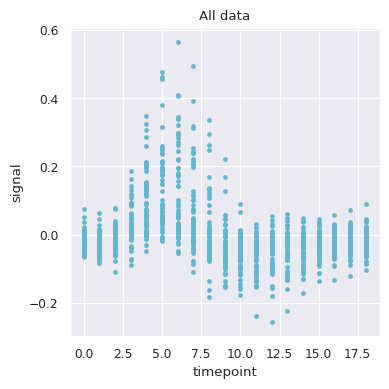

In [10]:
#+++++++ PLOT ALL DATA ++++++++++++++++++++
plt.figure(figsize=(4,4))
plt.plot(fmri["timepoint"], fmri["signal"],'c.')
plt.xlabel("timepoint")
plt.ylabel("signal")
plt.title('All data')
#plt.grid()
plt.show()

In [11]:
#CutS in the DataFrame IN ORDER TO SEE  a clean behaviour
parstim = fmri[np.logical_and(fmri.event == 'stim', fmri.region == 'parietal')]
parstim = parstim.reset_index()
del parstim['index'] #Reset index
parcue = fmri[np.logical_and(fmri.event == 'cue', fmri.region == 'parietal')]
parcue = parcue.reset_index()
del parcue['index']

fronstim = fmri[np.logical_and(fmri.event == 'stim', fmri.region == 'frontal')]
fronstim = fronstim.reset_index()
del fronstim['index']
froncue = fmri[np.logical_and(fmri.event == 'cue', fmri.region == 'frontal')]
froncue = froncue.reset_index()
del froncue['index']

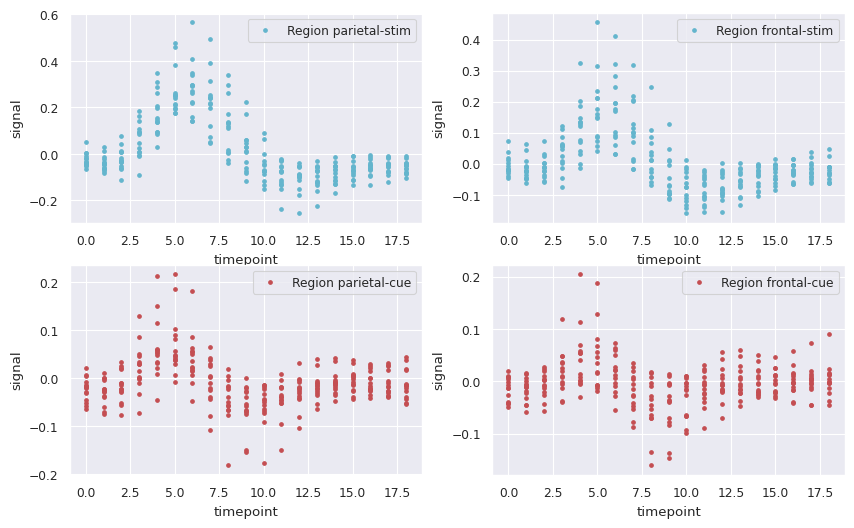

In [12]:
# Create a figure and a 2x2 grid of axes
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))

#PARIETAL STIM
ax[0,0].plot(parstim["timepoint"], parstim["signal"],'c.')
ax[0,0].set_xlabel("timepoint")
ax[0,0].set_ylabel("signal")
ax[0,0].legend(['Region parietal-stim'])
#PARIETAL CUE
ax[1,0].plot(parcue["timepoint"], parcue["signal"],'r.')
ax[1,0].set_xlabel("timepoint")
ax[1,0].set_ylabel("signal")
ax[1,0].legend(['Region parietal-cue'])

#FRONTAL STIM
ax[0,1].plot(fronstim["timepoint"], fronstim["signal"],'c.')
ax[0,1].set_xlabel("timepoint")
ax[0,1].set_ylabel("signal")
ax[0,1].legend(['Region frontal-stim'])
#FRONTAL CUE
ax[1,1].plot(froncue["timepoint"], froncue["signal"],'r.')
ax[1,1].set_xlabel("timepoint")
ax[1,1].set_ylabel("signal")
ax[1,1].legend(['Region frontal-cue'])

plt.show()

[-0.0012938   0.02054071 -0.01550556] 7.164290766925498e-07


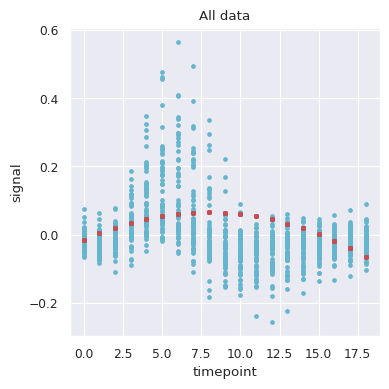

In [49]:
#Tray to do the fit...
from scipy.optimize import curve_fit

def curve_function(x, a, b, c):
    return a*x + b*np.cos(x) + c*np.sin(x)

# perform our curve fit
parameter, covariance = curve_fit(curve_function, parstim.timepoint, parstim.signal)
print(parameter,covariance[0][0])

plt.figure(figsize=(4,4))
plt.plot(fmri["timepoint"], fmri["signal"],'c.')
plt.plot(parstim.timepoint, np.polyval(parameter, parstim.timepoint),'r.')
plt.xlabel("timepoint")
plt.ylabel("signal")
plt.title('All data')
plt.show()

As you can see it doesn't work. We need todo a statistical analysis.

Homework: Tray to do a better fit.

In [14]:
# Look for the mean value in each bin (x,x+\deta x): function
signal_j = []
signal_k = []

for j in range(parstim.timepoint.min(),parstim.timepoint.max()+1):
  s = 0
  n = 0
  for i in range(0,len(parstim)):
    if parstim.timepoint[i] == j:

      s += parstim.signal[i]
      n += 1
  signal_j.append(s/n)

signal_k = []

for j in range(parcue.timepoint.min(),parcue.timepoint.max()+1):
  s = 0
  n = 0
  for i in range(0,len(parstim)):
    if parcue.timepoint[i] == j:

      s += parcue.signal[i]
      n += 1
  signal_k.append(s/n)

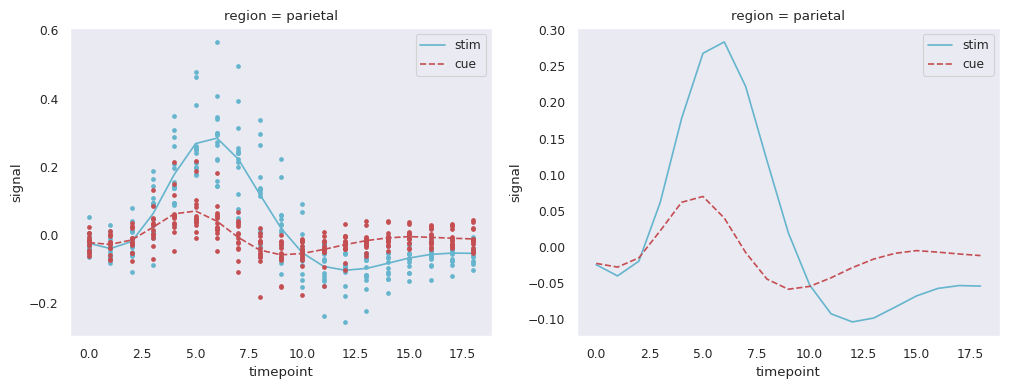

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
ax[0].plot(signal_j,'c-',label='stim')
ax[0].plot(parstim.timepoint,parstim.signal, 'c.')
ax[0].plot(parcue.timepoint,parcue.signal, 'r.')
ax[0].plot(signal_k,'r--',label='cue')
ax[0].grid()
ax[0].set_xlabel("timepoint")
ax[0].set_ylabel("signal")
ax[0].set_title('region = parietal')
ax[0].legend()
#+++++++++++++
ax[1].plot(signal_j,'c-',label='stim')
ax[1].plot(signal_k,'r--',label='cue')
ax[1].grid()
ax[1].set_xlabel("timepoint")
ax[1].set_ylabel("signal")
ax[1].set_title('region = parietal')
ax[1].legend()

plt.show()

In the last figure we can see the good plot, we some statistical analysis...

## Example: The same, but It is done directly with seaborn library

The following example demonstrates the creation of a figure with seaborn. The example makes use of one of the built-in datasets that are provided for documentation and generation of reproducible bug reports. It illustrates several of the features described in the Overview section,
including the declarative API, semantic mappings, faceting across subplots, aggregation with error bars, and visual theme control.

Using directly seaborn:

In [16]:
#Import data
fmri = sns.load_dataset("fmri")
#diplay
fmri[:2]

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883


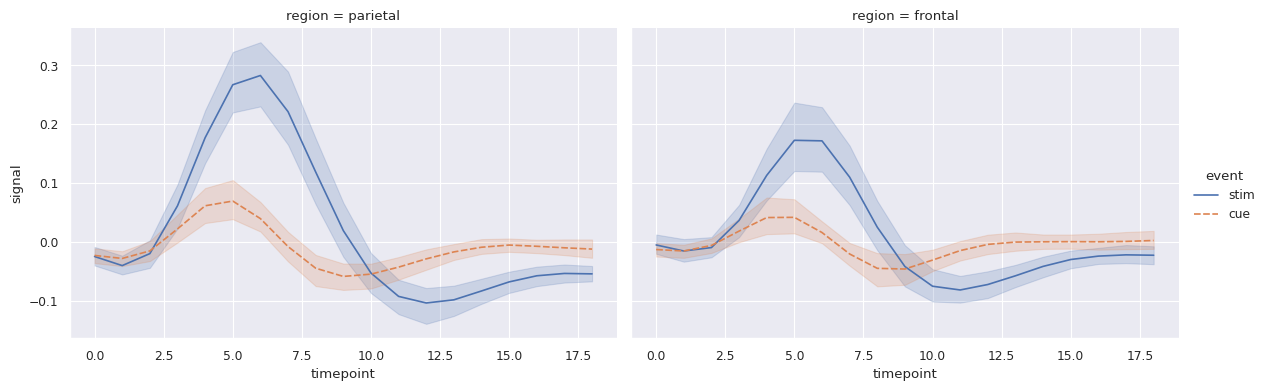

In [4]:
#import seaborn as sns

sns.set_theme(context="paper")
fmri = sns.load_dataset("fmri")
g = sns.relplot(
data=fmri, kind="line",
x="timepoint", y="signal",
hue="event", style="event", col="region",
height=4, aspect=1.5,)
#g.savefig("paper_demo.pdf")

We realize that the statistical analysis is done with some short lines...

Note:

* Functions in seaborn are classified as either “axes-level” or
“figure-level.”
1.  Axes-level functions behave like most plotting functions in the matplotlib.
2. Figure-level functions create their own figure when invoked, allowing them to “facet” the dataset by creating multiple conditional subplots, along with adding conveniences such as putting
the legend outside the space of the plot by default.

# TUTORIAL BÁSICO:

1. Gráficos básicos (en Ciencia de Datos)
2. Personalización de gráficos

## 1. Gráficos básicos

Veamos lo sencillo que resulta generar varios tipos de gráficos de uso común al realizar Análisis Exploratorio de Datos en Python.

Comencemos leyendo los sets de datos:

* **apple_stock.csv** Son los datos de apple con las variaciones de las acción de la empresa apple en la bolsa.
* **millas_por_galon.csv** Infomracción de millas por galón de los diferentes automóviles en el mundo

In [ ]:
#CARGAR ARCHIVOS desde Drive

from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

#Read from drive
path = '/content/drive/MyDrive/Colab Notebooks/Fundamentos_de_computación/Clases_notebooks/'
filename1 = 'apple_stock.csv'
filename2 = 'millas_por_galon.csv'

#para leer
df_apple = pd.read_csv(path+filename1, parse_dates=['ds'])
df_mpg = pd.read_csv(path+filename2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


parse_dates es el formato day time de pandas

### Line plots:
The are used in time series.
In this example we will use 'lineplot' of seaborn.

In [63]:
df_apple[:2]

,unique_id,ds,y
0,AAPL,2015-07-01,28.354204
1,AAPL,2015-07-02,28.318369


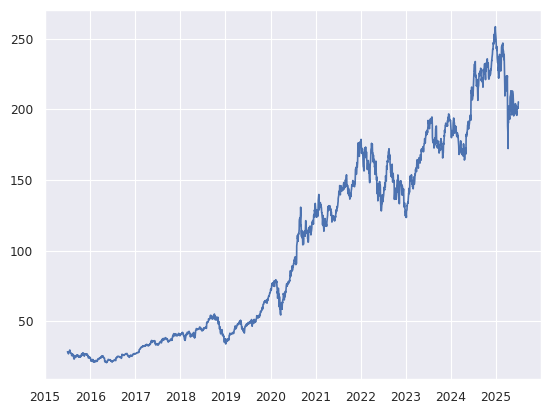

In [64]:
#Plot directly using matplolib
plt.plot(df_apple['ds'],df_apple['y'])

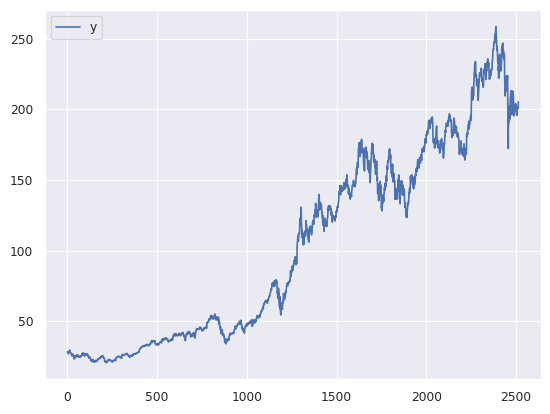

In [65]:
#Plot directly using seaborn library
#import seaborn as sns
sns.lineplot(data=df_apple);

lineplot show the behaviour of the line to analice. In this dataset we only have one numerical value.

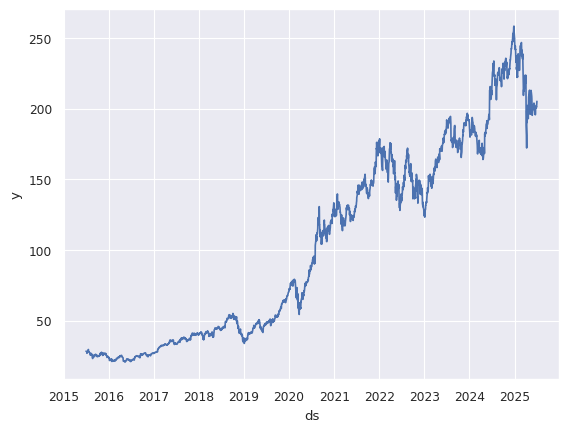

In [66]:
#with axis
sns.lineplot(data=df_apple, x='ds', y='y');

Important: Además, podemos definir una figura vacía de Matplotlib para poder controlar el tamaño del gráfico de Seaborn:

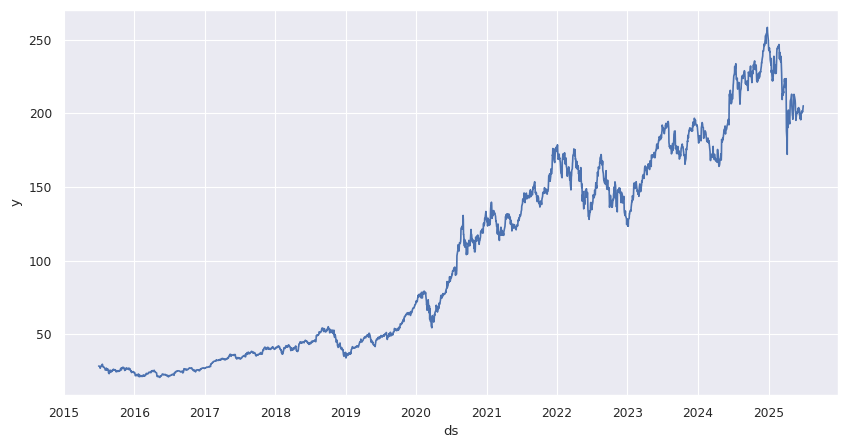

In [68]:
#import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_apple, x='ds', y='y', ax=ax);

I can use "lineplot" some times to do some plots in one canvas.
For example, we could plot the medium value in time.

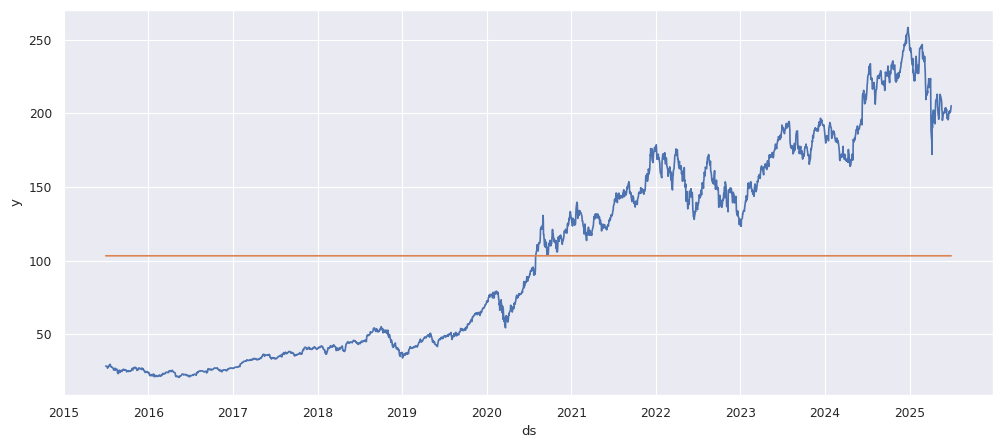

In [69]:
# Calcular el promedio histórico de la serie
df_apple['y_media'] = df_apple['y'].mean()

# Y dibujar las dos series
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=df_apple, x='ds', y='y', ax=ax)
sns.lineplot(data=df_apple, x='ds', y='y_media', ax=ax);

###histograma plots

They are used in Data science. We can see the data distibution.

We will use "histplot":

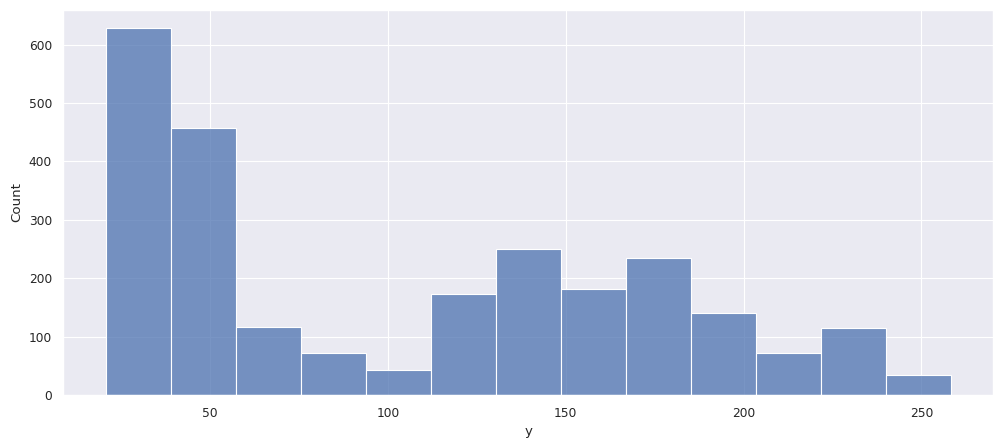

In [70]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(data=df_apple, x='y', ax=ax);

We see bins with values of the stock in time (acción de la empresa en USA). The commun values...

In next we will use "kde=True" to plot the estimation of distribution probability:

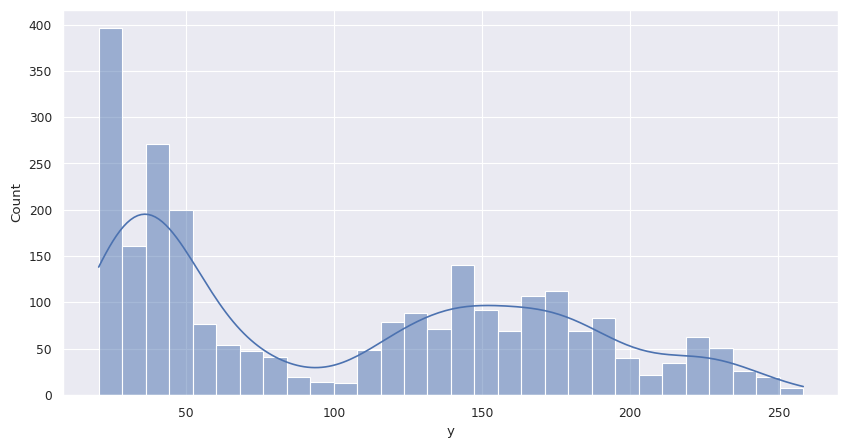

In [76]:
# Gráfico de histograma con KDE
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df_apple, x='y', bins=30, ax=ax, kde=True);

### Box plots:
Los gráficos de caja (o *box plots*) son otra herramienta muy útil en la exploración de datos. Además de permitirnos ver la distribución de los datos, facilitan detectar posibles "outliers".

Para generar estos gráficos usamos "boxplot":

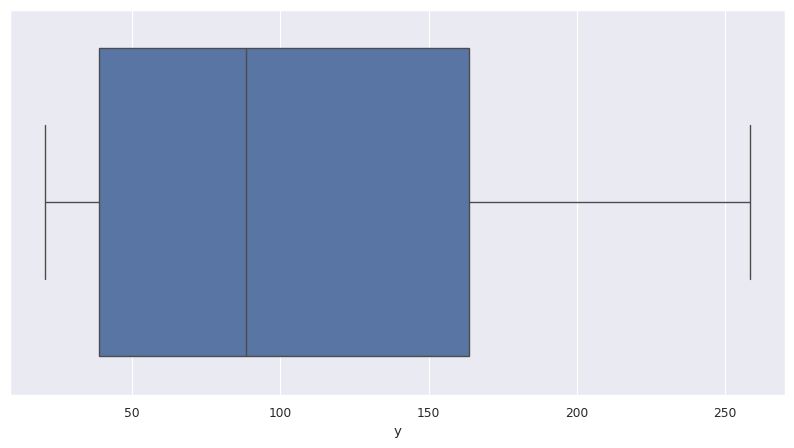

In [78]:
# Boxplot
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_apple, x='y', ax=ax);

In [84]:
df_mpg[:1]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu


Todos los gráficos anteriores usan únicamente variables numéricas. Pero podemos enriquecer estos gráficos incluyendo variables categóricas.

Por ejemplo, dibujemos los histogramas para la variable potencia del vehículo "horsepower" pero diferenciándolos por país de fabricación del vehículo ("origin"):

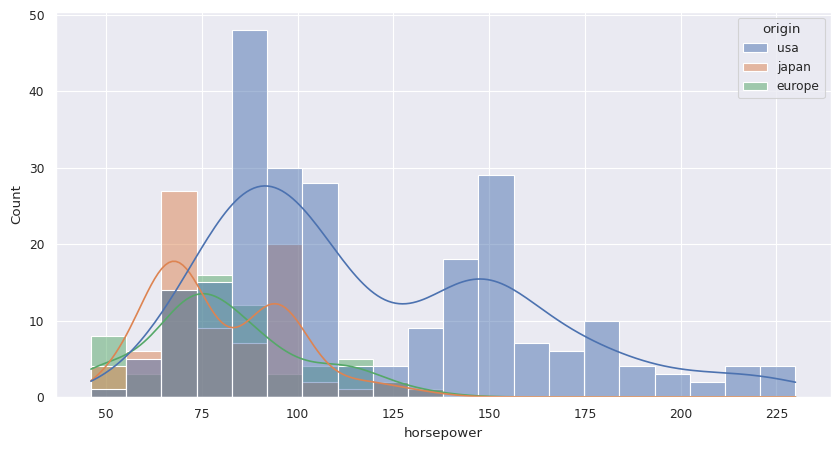

In [85]:
# Histograma combinado horswepower por país
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df_mpg, x='horsepower', hue='origin', bins=20, kde=True, ax=ax);

We can see the distribution of horsepower for each country. Also we show the distribution probability.

### Scatter plos

Los gráficos de dispersión resultan útiles cuando hacemos análisis bivariado, es decir cuando queremos comparar pares de variables **numéricas**.

Por ejemplo, en el set de datos "df_mpg" comparemos las millas por galón ("mpg") con la potencia del vehículo ("horsepower"). Para generar este gráfico usamos "scatterplot":

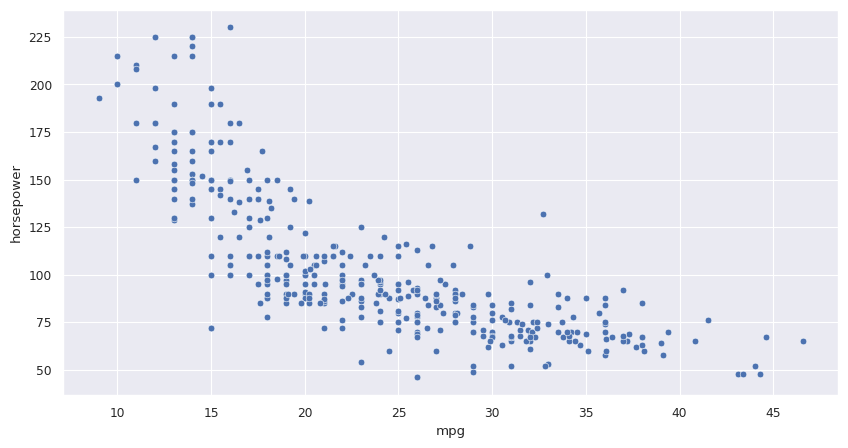

In [80]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=df_mpg, x='mpg', y='horsepower', ax=ax);

**Homework**: construct the fit to the data at $95$ C.L. Hcer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower).

### relplot

Podemos usar "relplot" que es una versión modificada de "scatterplot" pero que nos permite incluir variables categóricas.

Por ejemplo, dibujemos el gráfico de dispersión "horsepower" vs. "mpg" anterior. Sin embargo ahora:

- Haremos que el color de cada punto sea diferente para cada país de origen
- Y que el tamaño de cada círculo sea proporcinal al peso del vehículo

In [88]:
df_mpg[:2]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320


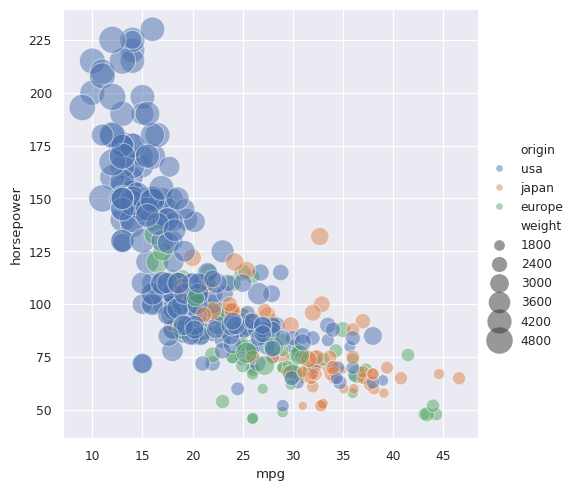

In [86]:
sns.relplot(data=df_mpg, x="mpg", y="horsepower", hue="origin", size="weight",
            sizes=(40, 400), alpha=.5, );

### pairplots
Los "pairplots" son útiles para comparar de manera simultánea más de dos variables numéricas.

Por ejemplo, comparemos las columnas "mpg", "horsepower" y "weight" y veamos el resultado:

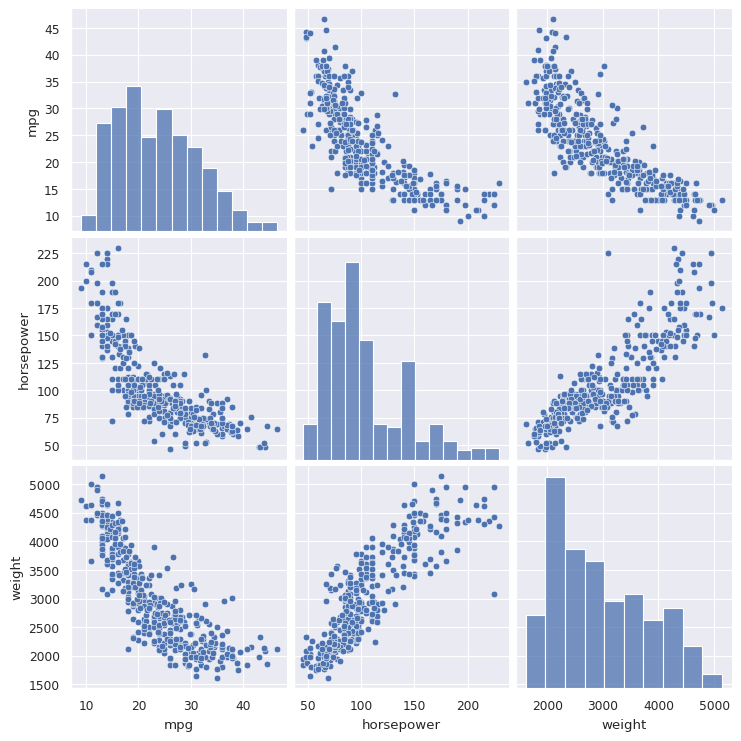

In [90]:
sns.pairplot(df_mpg, vars=['mpg', 'horsepower', 'weight']);

## 3. Personalización de gráficos

Como en últimas un gráfico en Seaborn es en esencia un gráfico de Matplotlib, podemos controlar dicho gráfico accediendo por ejemplo a sus ejes (Axes).

Por ejemplo, dibujemos la serie de tiempo y añadamos título al gráfico y etiquetas a los ejes:

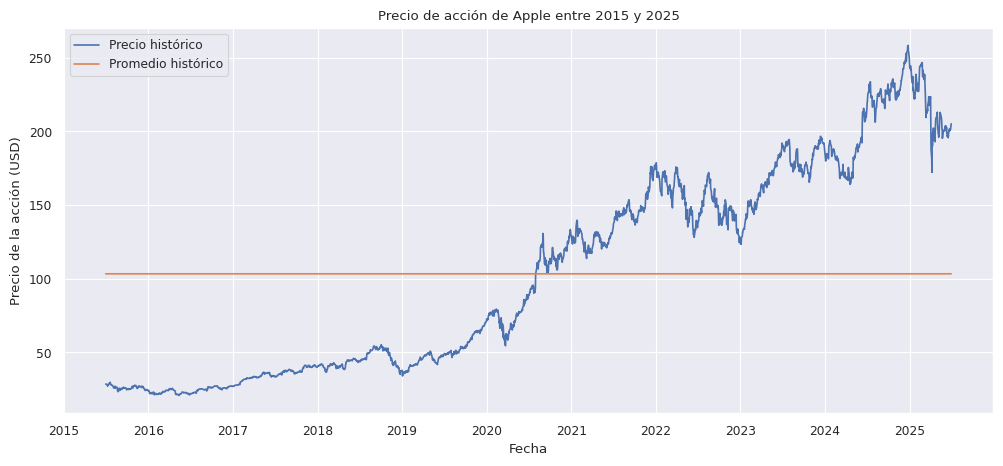

In [92]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=df_apple, x='ds', y='y', label='Precio histórico', ax=ax)
sns.lineplot(data=df_apple, x='ds', y='y_media', label='Promedio histórico', ax=ax);

# Etiquetar ejes
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio de la acción (USD)');
ax.set_title('Precio de acción de Apple entre 2015 y 2025')

# Agregar leyenda
ax.legend()

# Activar o desactivar grilla
ax.grid(True);

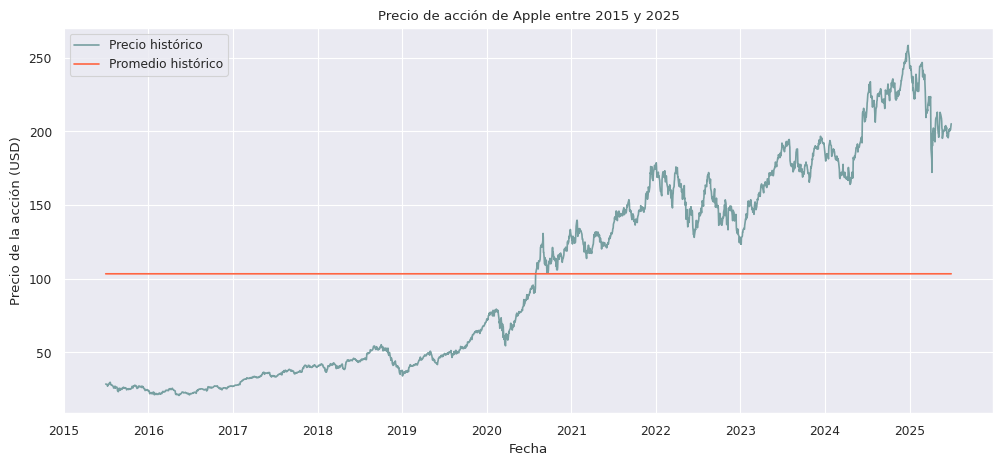

In [93]:
# Personalizando gráficas: líneas con diferentes colores
c1 = '#779FA1'
c2 = '#FF6542'

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=df_apple, x='ds', y='y', label='Precio histórico', color=c1, ax=ax)
sns.lineplot(data=df_apple, x='ds', y='y_media', label='Promedio histórico', color=c2, ax=ax);

# Etiquetar ejes
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio de la acción (USD)');
ax.set_title('Precio de acción de Apple entre 2015 y 2025')

# Agregar leyenda
ax.legend()

# Activar o desactivar grilla
ax.grid(True);

## 4. Exportación de imágenes

Y por último podemos exportar una figura en formato de imagen (PNG, JPG) con la resolución que queramos:

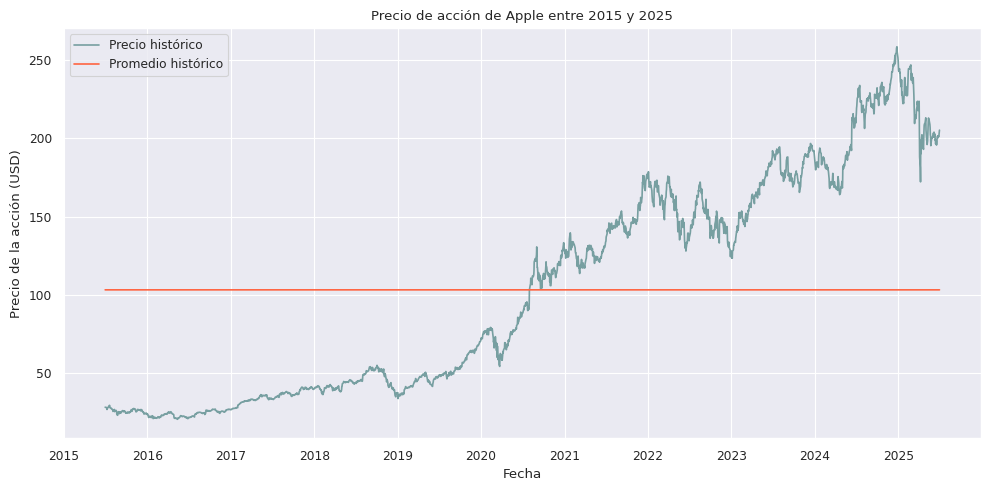

In [95]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_apple, x='ds', y='y', label='Precio histórico', color=c1, ax=ax)
sns.lineplot(data=df_apple, x='ds', y='y_media', label='Promedio histórico', color=c2, ax=ax);

# Etiquetar ejes
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio de la acción (USD)');
ax.set_title('Precio de acción de Apple entre 2015 y 2025')

# Agregar leyenda
ax.legend()

# Sugerido antes de exportar la figura
plt.tight_layout()

# Exportar figura
fig.savefig('precio_accion_apple.png', dpi=300);

## Lab_1_2

* Hacer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower) in the dataset: millas_por_galón.csv. Contruya el fit de al $95$ C.L.      

  

